In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')



#### Importing datasets (test & train)

In [2]:
df = pd.read_csv('drugsComTrain_raw.csv')
test = pd.read_csv('drugsComTest_raw.csv')

In [3]:
print("Shape of training dataset:", df.shape)
df.head()

Shape of training dataset: (161297, 7)


,uniqueID,drugName,condition,review,rating,date,usefulCount
0,206461,Valsartan,Left Ventricular Dysfunction,"""It has no side effect, I take it in combinati...",9,20-May-12,27
1,95260,Guanfacine,ADHD,"""My son is halfway through his fourth week of ...",8,27-Apr-10,192
2,92703,Lybrel,Birth Control,"""I used to take another oral contraceptive, wh...",5,14-Dec-09,17
3,138000,Ortho Evra,Birth Control,"""This is my first time using any form of birth...",8,3-Nov-15,10
4,35696,Buprenorphine / naloxone,Opiate Dependence,"""Suboxone has completely turned my life around...",9,27-Nov-16,37


In [4]:
print("Shape of testing dataset:", test.shape)
test.head()

Shape of testing dataset: (53766, 7)


,uniqueID,drugName,condition,review,rating,date,usefulCount
0,163740,Mirtazapine,Depression,"""I&#039;ve tried a few antidepressants over th...",10,28-Feb-12,22
1,206473,Mesalamine,"Crohn's Disease, Maintenance","""My son has Crohn&#039;s disease and has done ...",8,17-May-09,17
2,159672,Bactrim,Urinary Tract Infection,"""Quick reduction of symptoms""",9,29-Sep-17,3
3,39293,Contrave,Weight Loss,"""Contrave combines drugs that were used for al...",9,5-Mar-17,35
4,97768,Cyclafem 1 / 35,Birth Control,"""I have been on this birth control for one cyc...",9,22-Oct-15,4


In [5]:
# From the above two ouputs we can see that both the dataset contains same columns, we can combine them for better analysis

data = pd.concat([df, test])
print("Shape of dataset after combining both train & test:", data.shape)
data.head()

Shape of dataset after combining both train & test: (215063, 7)


,uniqueID,drugName,condition,review,rating,date,usefulCount
0,206461,Valsartan,Left Ventricular Dysfunction,"""It has no side effect, I take it in combinati...",9,20-May-12,27
1,95260,Guanfacine,ADHD,"""My son is halfway through his fourth week of ...",8,27-Apr-10,192
2,92703,Lybrel,Birth Control,"""I used to take another oral contraceptive, wh...",5,14-Dec-09,17
3,138000,Ortho Evra,Birth Control,"""This is my first time using any form of birth...",8,3-Nov-15,10
4,35696,Buprenorphine / naloxone,Opiate Dependence,"""Suboxone has completely turned my life around...",9,27-Nov-16,37


# Data Exploration

In [6]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
uniqueID,215063.0,116039.364814,67007.913366,0.0,58115.5,115867.0,173963.5,232291.0
rating,215063.0,6.990008,3.275554,1.0,5.0,8.0,10.0,10.0
usefulCount,215063.0,28.001004,36.346069,0.0,6.0,16.0,36.0,1291.0


In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 215063 entries, 0 to 53765
Data columns (total 7 columns):
 #   Column       Non-Null Count   Dtype 
---  ------       --------------   ----- 
 0   uniqueID     215063 non-null  int64 
 1   drugName     215063 non-null  object
 2   condition    213869 non-null  object
 3   review       215063 non-null  object
 4   rating       215063 non-null  int64 
 5   date         215063 non-null  object
 6   usefulCount  215063 non-null  int64 
dtypes: int64(3), object(4)
memory usage: 13.1+ MB


In [8]:
data.dtypes

uniqueID        int64
drugName       object
condition      object
review         object
rating          int64
date           object
usefulCount     int64
dtype: object

#### NaNs ?

In [9]:
data.isnull().any()

uniqueID       False
drugName       False
condition       True
review         False
rating         False
date           False
usefulCount    False
dtype: bool

We notice that we have some NaNs in "condition" column.

In [10]:
data.isnull().sum()

uniqueID          0
drugName          0
condition      1194
review            0
rating            0
date              0
usefulCount       0
dtype: int64

We have 1194 NaNs in "condition" column.

# Data Viz

#### Word cloud for Drug Names

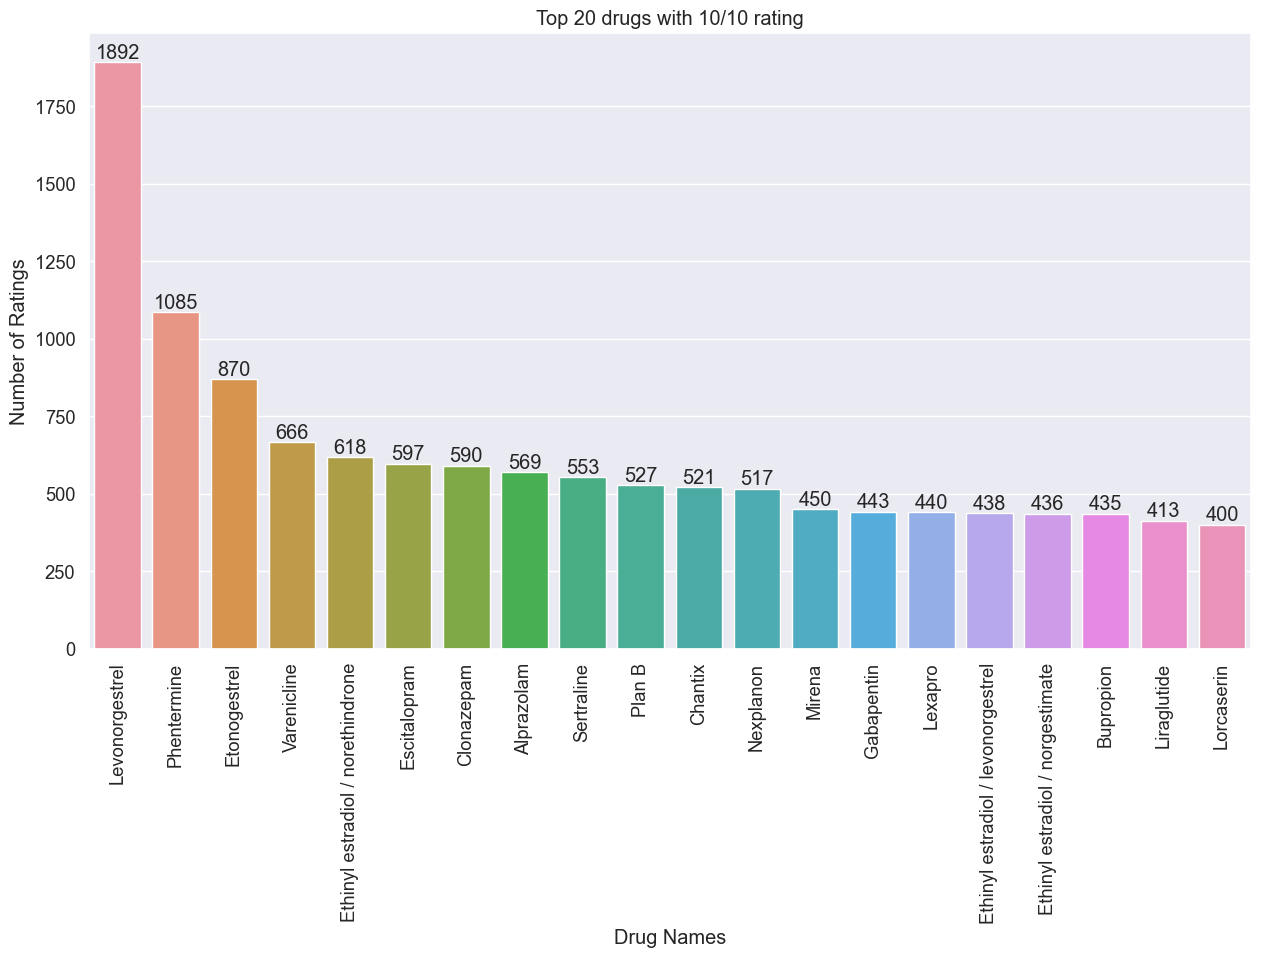

In [11]:
sns.set(font_scale = 1.2, style = 'darkgrid')
plt.rcParams['figure.figsize'] = [15, 8]

rating = dict(data.loc[data.rating == 10, "drugName"].value_counts())
drugname = list(rating.keys())
drug_rating = list(rating.values())

sns_rating = sns.barplot(x = drugname[0:20], y = drug_rating[0:20])

for i in sns_rating.containers:
    sns_rating.bar_label(i,)

sns_rating.set_title('Top 20 drugs with 10/10 rating')
sns_rating.set_ylabel("Number of Ratings")
sns_rating.set_xlabel("Drug Names")
plt.setp(sns_rating.get_xticklabels(), rotation=90)
plt.show()

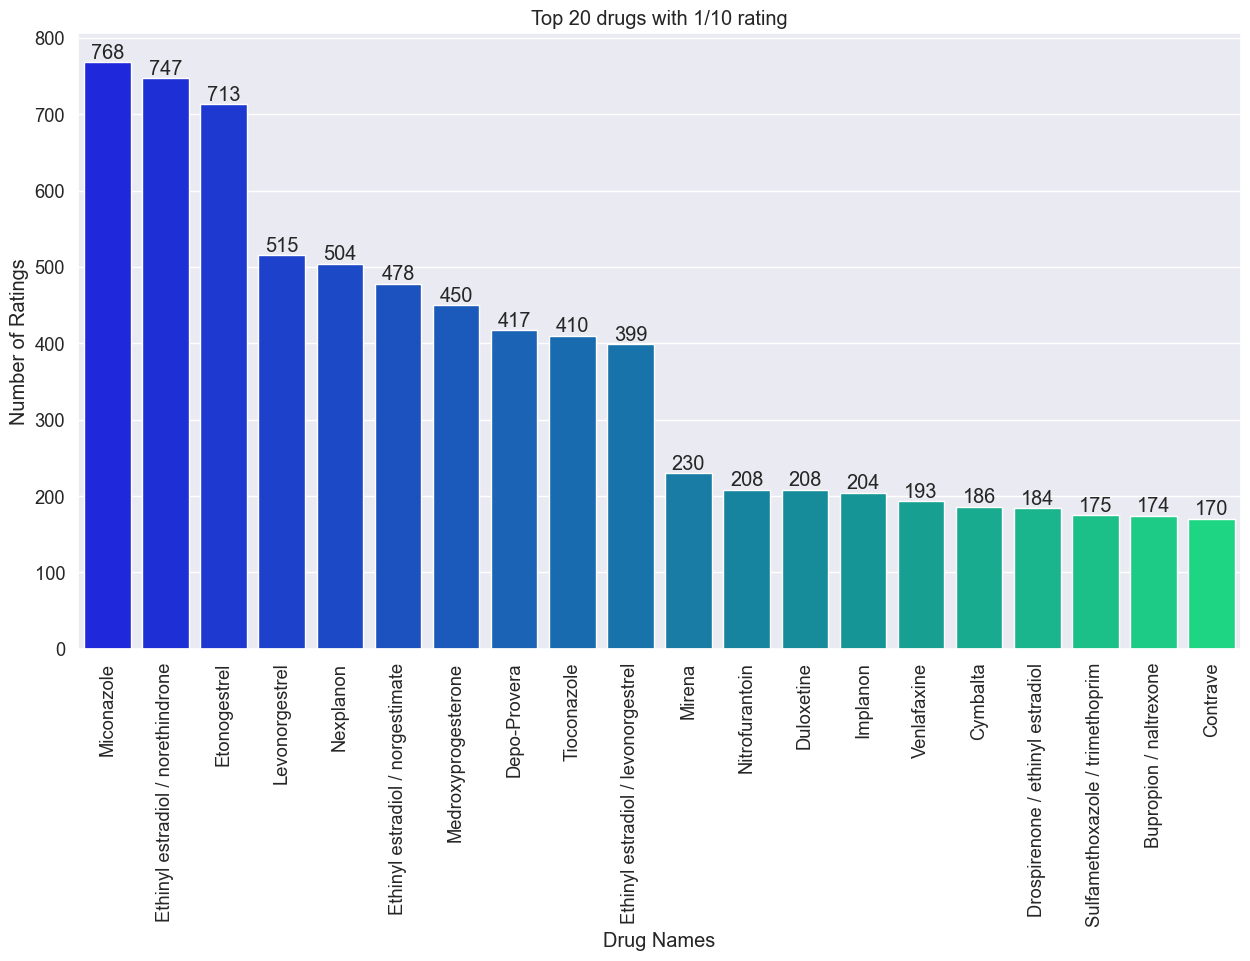

In [12]:
# Setting the Parameter
sns.set(font_scale = 1.2, style = 'darkgrid')
plt.rcParams['figure.figsize'] = [15, 8]

rating = dict(data.loc[data.rating == 1, "drugName"].value_counts())
drugname = list(rating.keys())
drug_rating = list(rating.values())

sns_rating = sns.barplot(x = drugname[0:20], y = drug_rating[0:20], palette = 'winter')

for i in sns_rating.containers:
    sns_rating.bar_label(i,)

sns_rating.set_title('Top 20 drugs with 1/10 rating')
sns_rating.set_ylabel("Number of Ratings")
sns_rating.set_xlabel("Drug Names")
plt.setp(sns_rating.get_xticklabels(), rotation=90)
plt.show()

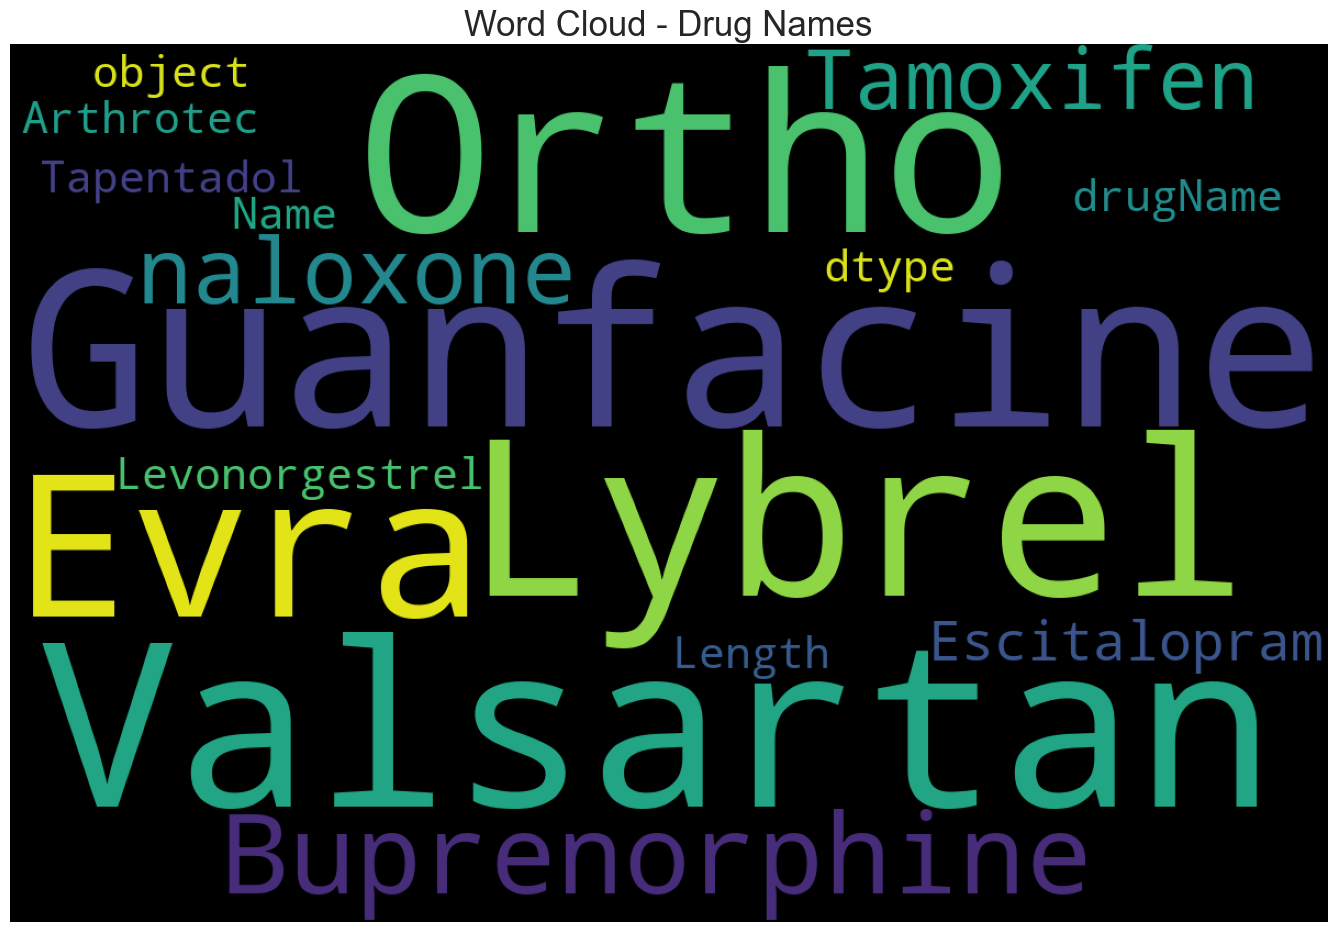

In [13]:
# let's see the words cloud for the reviews 

# most popular drugs

from wordcloud import WordCloud
from wordcloud import STOPWORDS

stopwords = set(STOPWORDS)

wordcloud = WordCloud(stopwords = stopwords, width = 1200, height = 800).generate(str(data['drugName']))

plt.rcParams['figure.figsize'] = (17, 17)
plt.title('Word Cloud - Drug Names', fontsize = 25)
print(wordcloud)
plt.axis('off')
plt.imshow(wordcloud)
plt.show()

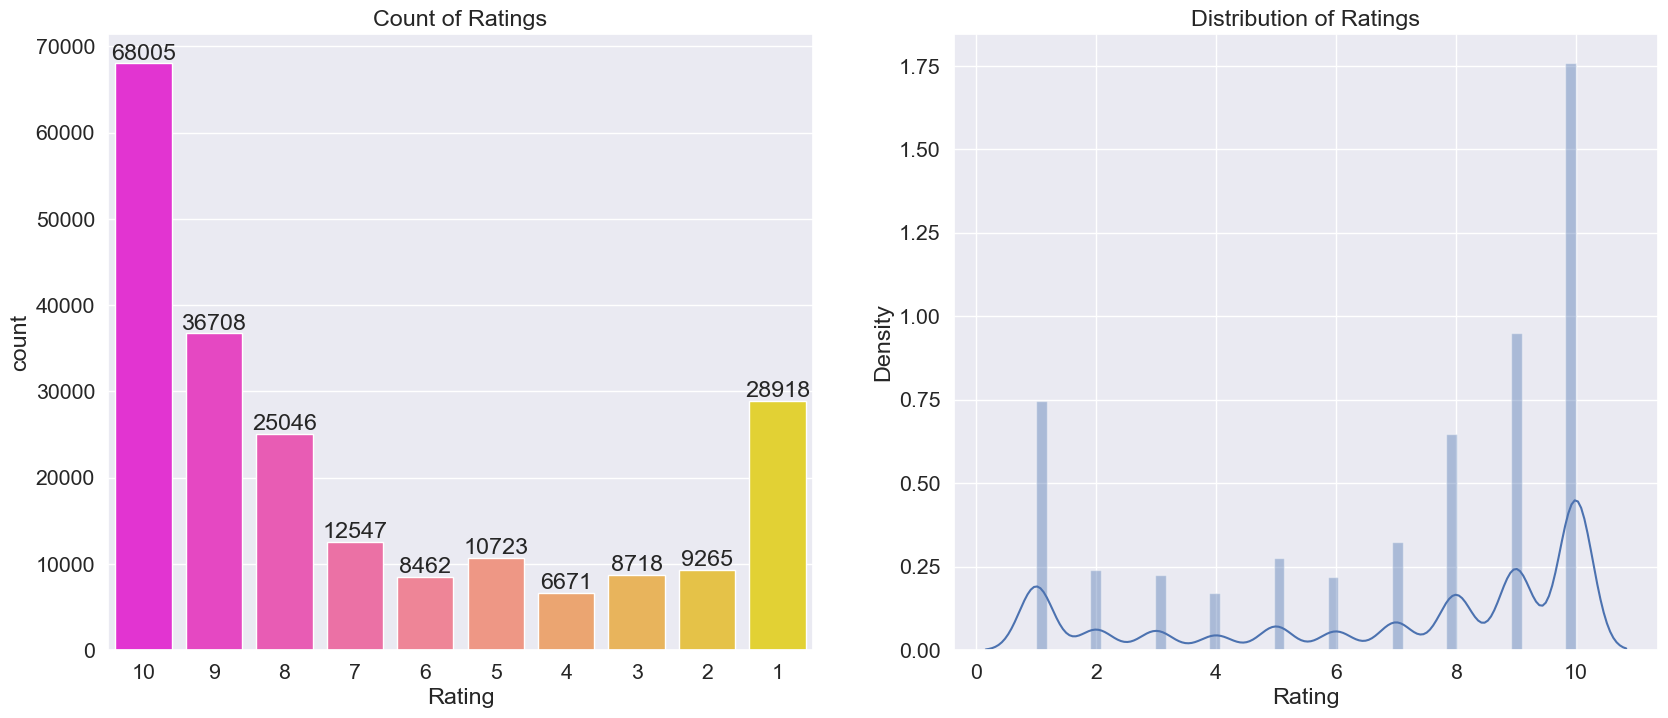

In [14]:
plt.rcParams['figure.figsize'] = [20,8]
sns.set(font_scale = 1.4, style = 'darkgrid')
fig, ax = plt.subplots(1, 2)

sns_1 = sns.countplot(data['rating'], palette = 'spring', order = list(range(10, 0, -1)), ax = ax[0])

for i in sns_1.containers:
    sns_1.bar_label(i,)
    
sns_2 = sns.distplot(data['rating'], ax = ax[1])
sns_1.set_title('Count of Ratings')
sns_1.set_xlabel("Rating")

sns_2.set_title('Distribution of Ratings')
sns_2.set_xlabel("Rating")
plt.show()

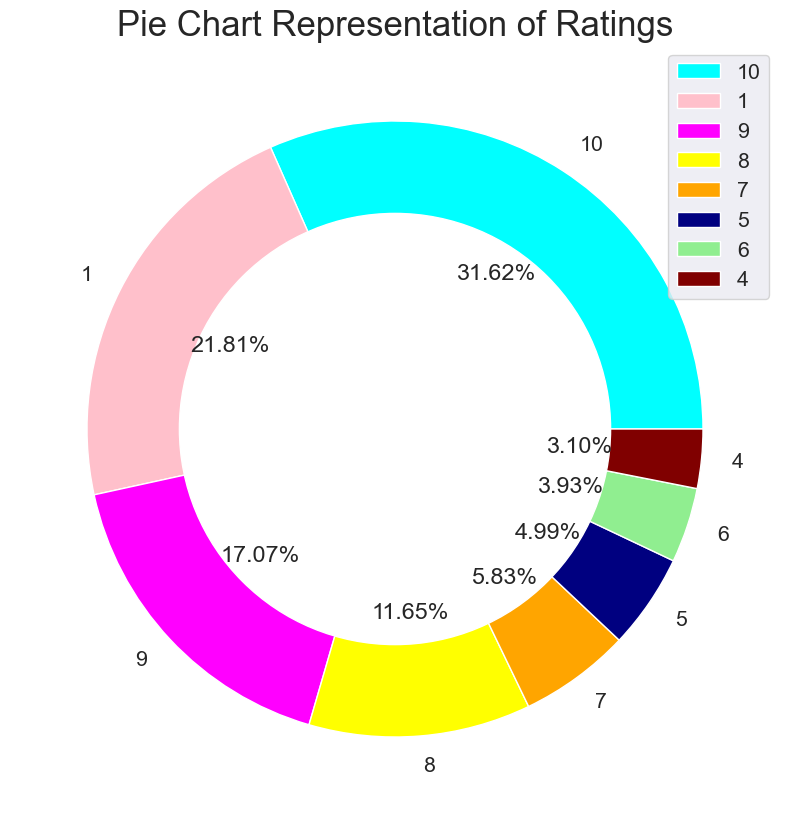

In [15]:
size = [68005, 46901, 36708, 25046, 12547, 10723, 8462, 6671]
colors = ['cyan', 'pink', 'magenta',  'yellow', 'orange', 'navy', 'lightgreen', 'maroon']
labels = "10", "1", "9", "8", "7", "5", "6", "4"

my_circle = plt.Circle((0, 0), 0.7, color = 'white')

plt.rcParams['figure.figsize'] = (10, 10)
plt.pie(size, colors = colors, labels = labels, autopct = '%.2f%%')
plt.axis('off')
plt.title('Pie Chart Representation of Ratings', fontsize = 25)
p = plt.gcf()
plt.gca().add_artist(my_circle)
plt.legend()
plt.show()

Text(0, 0.5, 'Count')

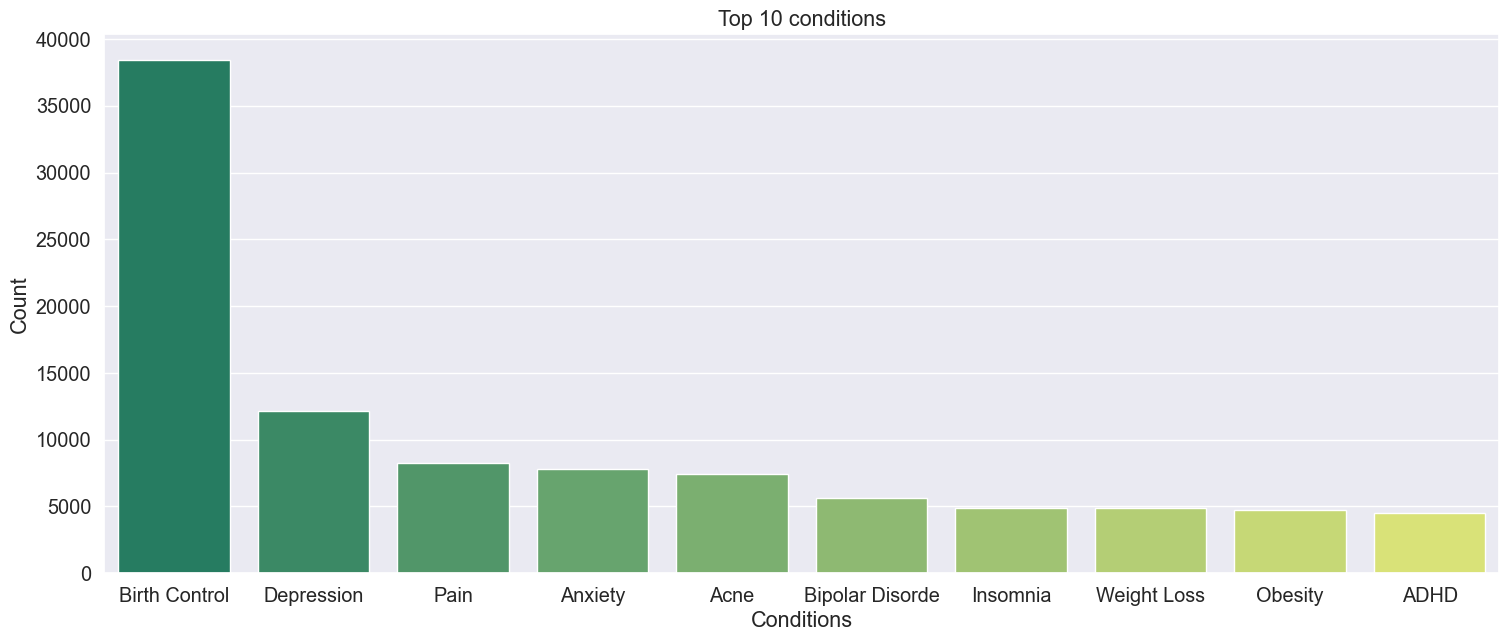

In [16]:
cond = dict(data['condition'].value_counts())
top_condition = list(cond.keys())[0:10]
values = list(cond.values())[0:10]
sns.set(style = 'darkgrid', font_scale = 1.3)
plt.rcParams['figure.figsize'] = [18, 7]

sns_ = sns.barplot(x = top_condition, y = values, palette = 'summer')
sns_.set_title("Top 10 conditions")
sns_.set_xlabel("Conditions")
sns_.set_ylabel("Count")

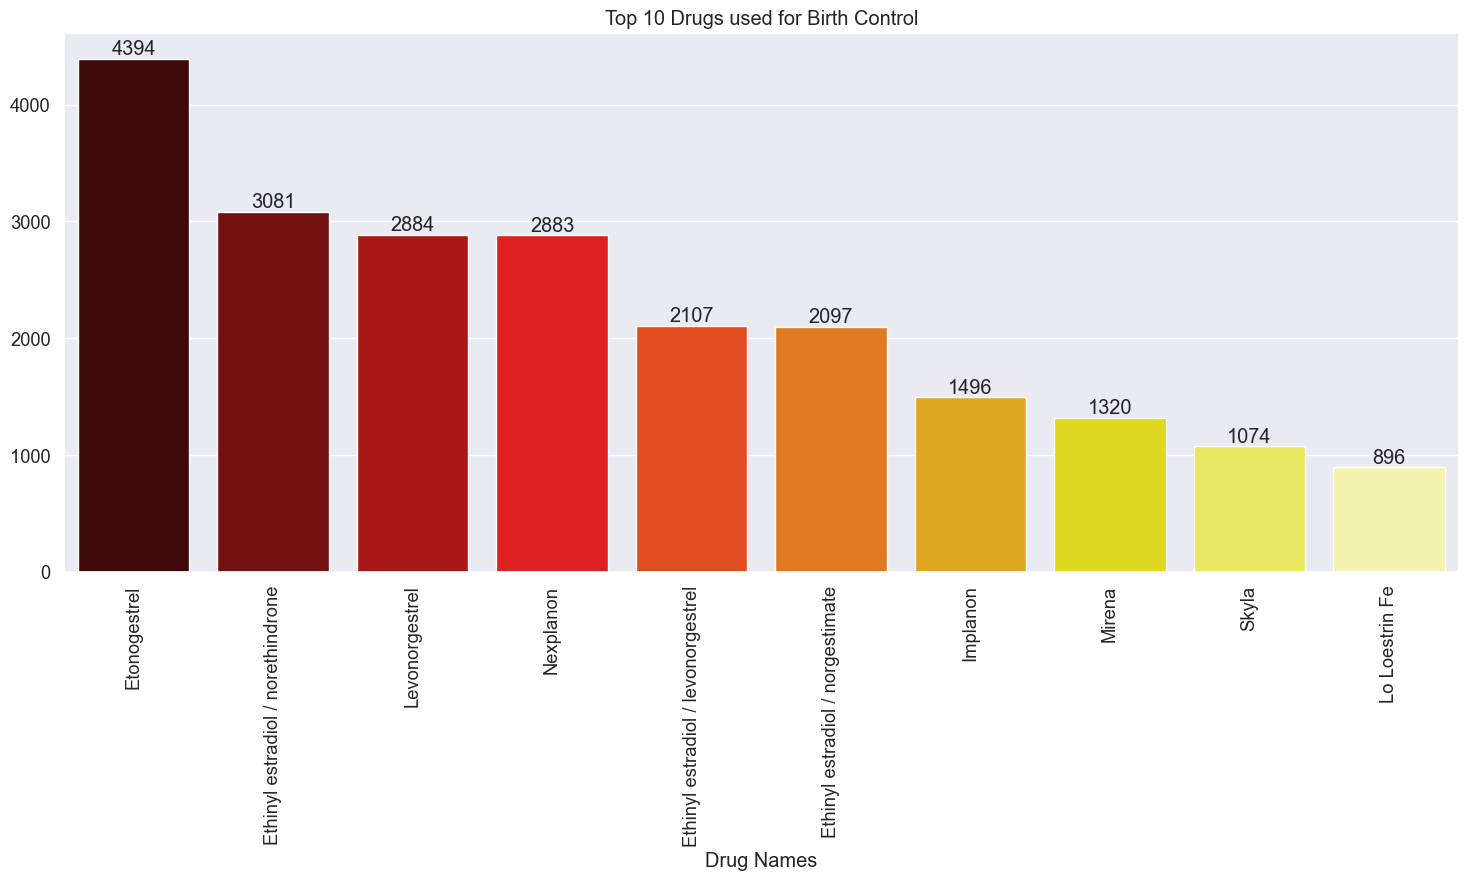

In [17]:
df1 = data[data['condition'] == 'Birth Control']['drugName'].value_counts()[0: 10]
sns.set(font_scale = 1.2, style = 'darkgrid')

sns_ = sns.barplot(x = df1.index, y = df1.values, palette = 'hot')

for i in sns_.containers:
    sns_.bar_label(i,)
    
sns_.set_xlabel('Drug Names')
sns_.set_title("Top 10 Drugs used for Birth Control")
plt.setp(sns_.get_xticklabels(), rotation = 90)
plt.show()

In [18]:
# feature engineering 
# let's make a new column named "review sentiment"

data.loc[(data['rating'] >= 5), 'Review_Sentiment'] = 1
data.loc[(data['rating'] < 5), 'Review_Sentiment'] = 0

data['Review_Sentiment'].value_counts()

1.0    161491
0.0     53572
Name: Review_Sentiment, dtype: int64

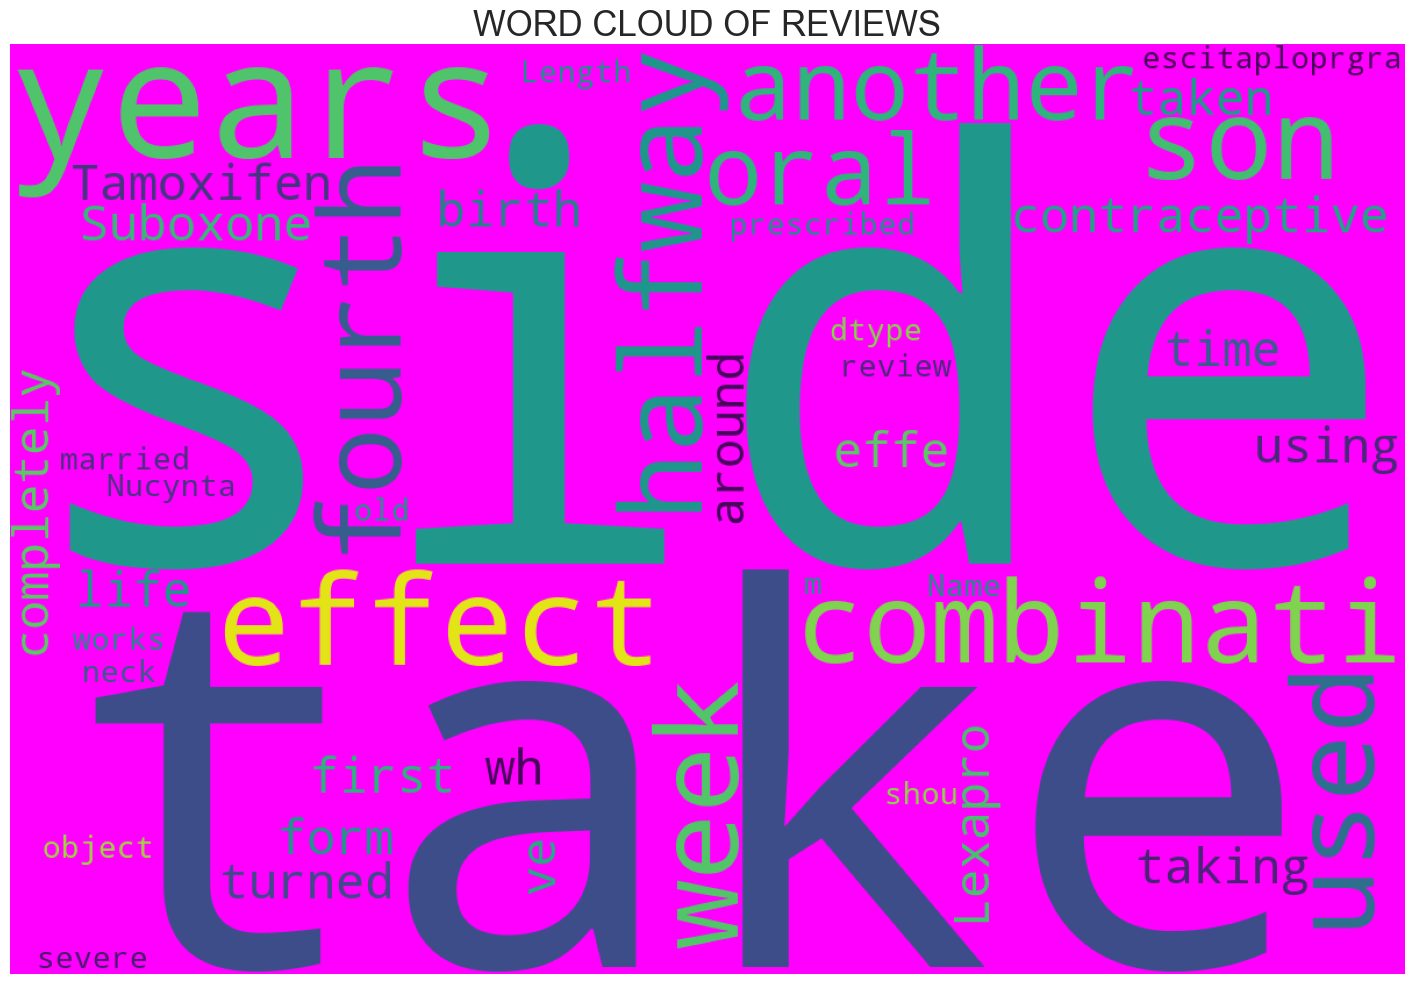

In [19]:
stopwords = set(STOPWORDS)

wordcloud = WordCloud(background_color = 'magenta', stopwords = stopwords, width = 1200, height = 800).generate(str(data['review']))

plt.rcParams['figure.figsize'] = (18, 15)
plt.title('WORD CLOUD OF REVIEWS', fontsize = 25)
print(wordcloud)
plt.axis('off')
plt.imshow(wordcloud)
plt.show()

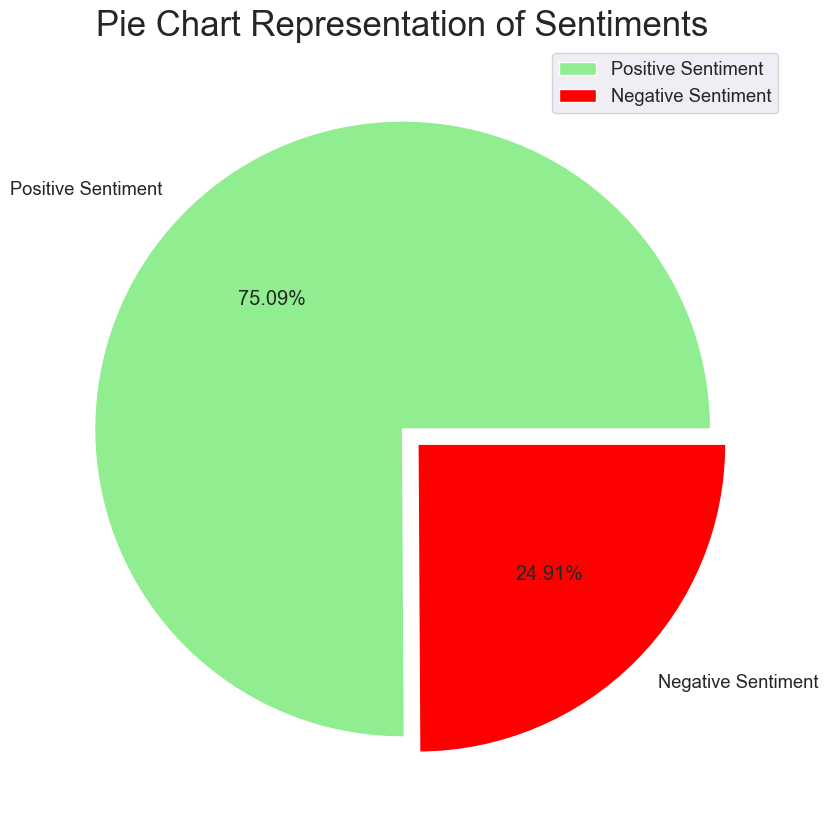

In [20]:
size = [161491, 53572]
colors = ['lightgreen', 'red']
labels = "Positive Sentiment","Negative Sentiment"
explode = [0, 0.07]

plt.rcParams['figure.figsize'] = (10, 10)
plt.pie(size, colors = colors, labels = labels, explode = explode, autopct = '%.2f%%')
plt.axis('off')
plt.title('Pie Chart Representation of Sentiments', fontsize = 25)
plt.legend()
plt.show()

In [21]:
data.columns

Index(['uniqueID', 'drugName', 'condition', 'review', 'rating', 'date',
       'usefulCount', 'Review_Sentiment'],
      dtype='object')

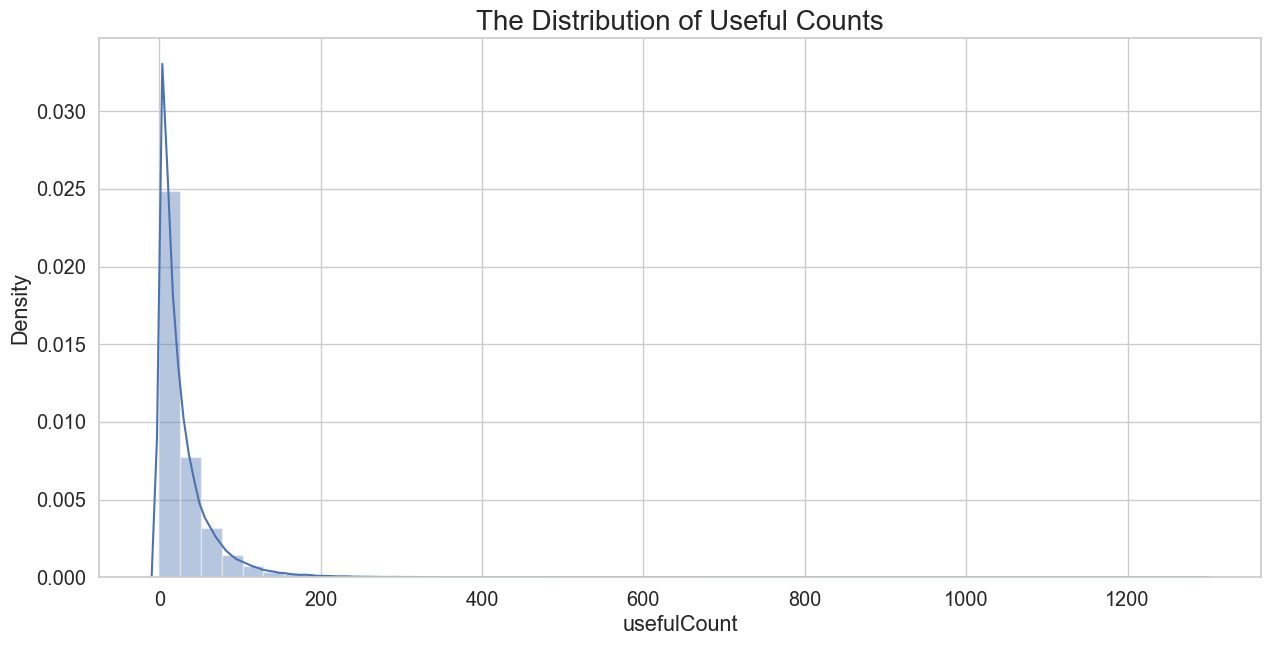

In [22]:
sns.set(style = 'whitegrid', font_scale = 1.3)
plt.rcParams['figure.figsize'] = [15, 7]
sns.distplot(data['usefulCount'].dropna())
plt.title('The Distribution of Useful Counts', fontsize = 20)
plt.show()

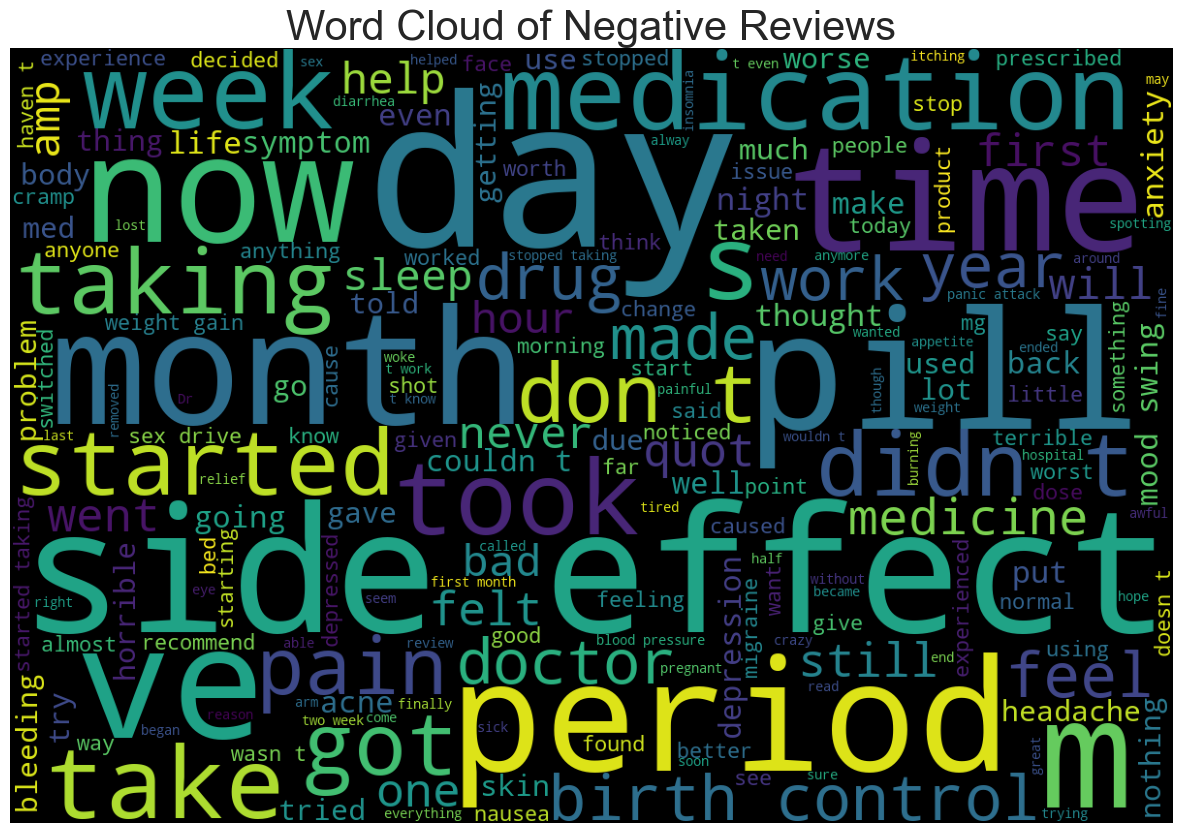

In [23]:
negative_sentiments = " ".join([text for text in data['review'][data['Review_Sentiment'] == 0]])

stopwords = set(STOPWORDS)
wordcloud = WordCloud(stopwords = stopwords, width = 1200, height = 800).generate(negative_sentiments)

plt.rcParams['figure.figsize'] = (15, 15)
plt.title('Word Cloud of Negative Reviews', fontsize = 30)
print(wordcloud)
plt.axis('off')
plt.imshow(wordcloud)
plt.show()

In [24]:
positive_sentiments = " ".join([text for text in data['review'][data['Review_Sentiment'] == 1]])

from wordcloud import WordCloud
from wordcloud import STOPWORDS

stopwords = set(STOPWORDS)
wordcloud = WordCloud(background_color = 'cyan', stopwords = stopwords, width = 1200, height = 800).generate(positive_sentiments)

plt.rcParams['figure.figsize'] = (15, 15)
plt.title('Word Cloud of Positive Reviews', fontsize = 30)
print(wordcloud)
plt.axis('off')
plt.imshow(wordcloud)
plt.show()

KeyboardInterrupt: 

#### Transforming date column

In [ ]:
# converting the date into datetime format
data['date'] = pd.to_datetime(data['date'], errors = 'coerce')

# extracting year from date
data['Year'] = data['date'].dt.year

# extracting the month from the date
data['month'] = data['date'].dt.month

# extracting the days from the date
data['day'] = data['date'].dt.day

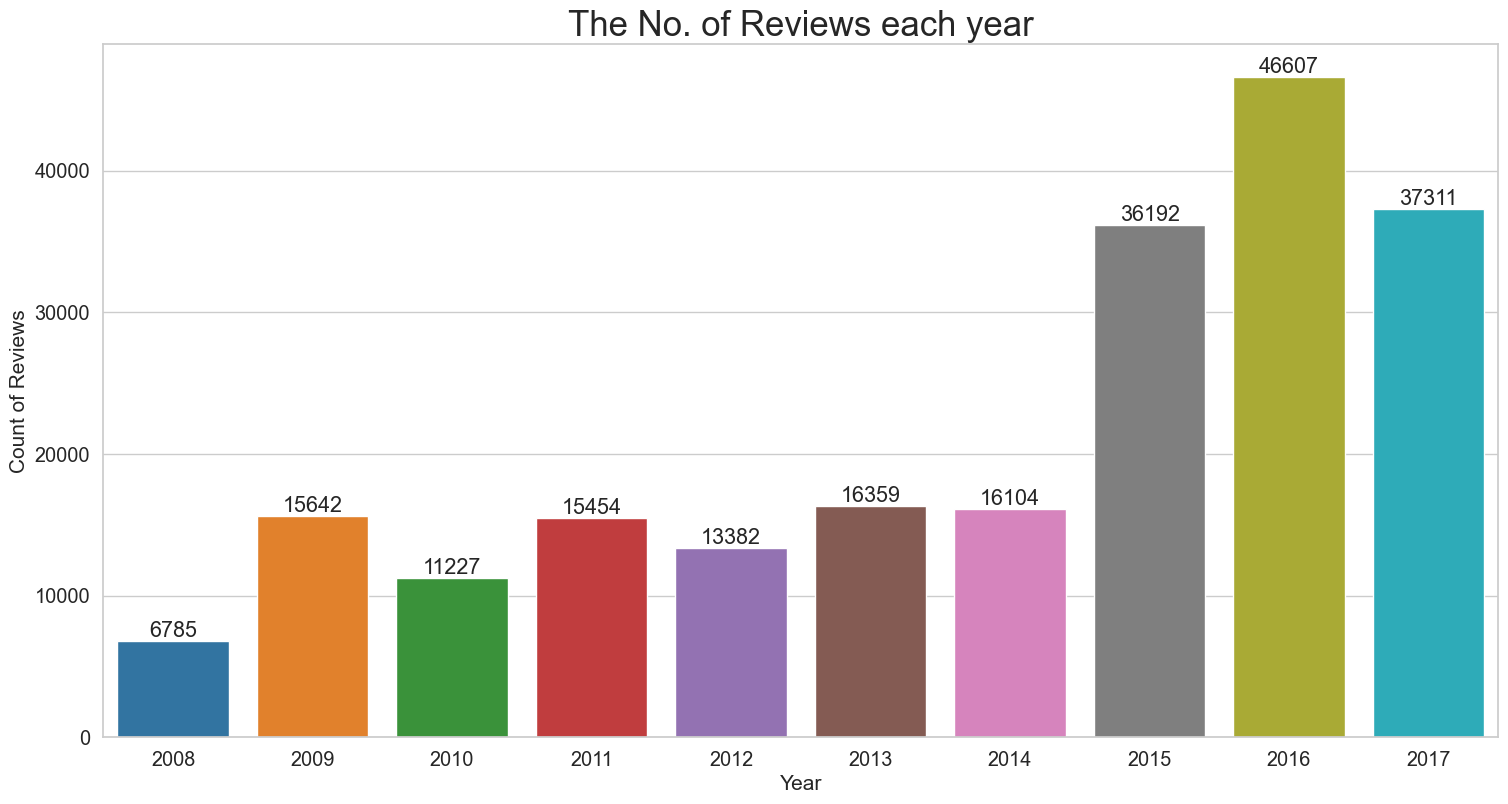

In [ ]:
plt.rcParams['figure.figsize'] = (18, 9)
sns_=sns.countplot(data['Year'], palette ='tab10')

for i in sns_.containers:
    sns_.bar_label(i,)
    
plt.title('The No. of Reviews each year', fontsize = 25)
plt.xlabel('Year', fontsize = 15)
plt.ylabel('Count of Reviews', fontsize = 15)
plt.show()

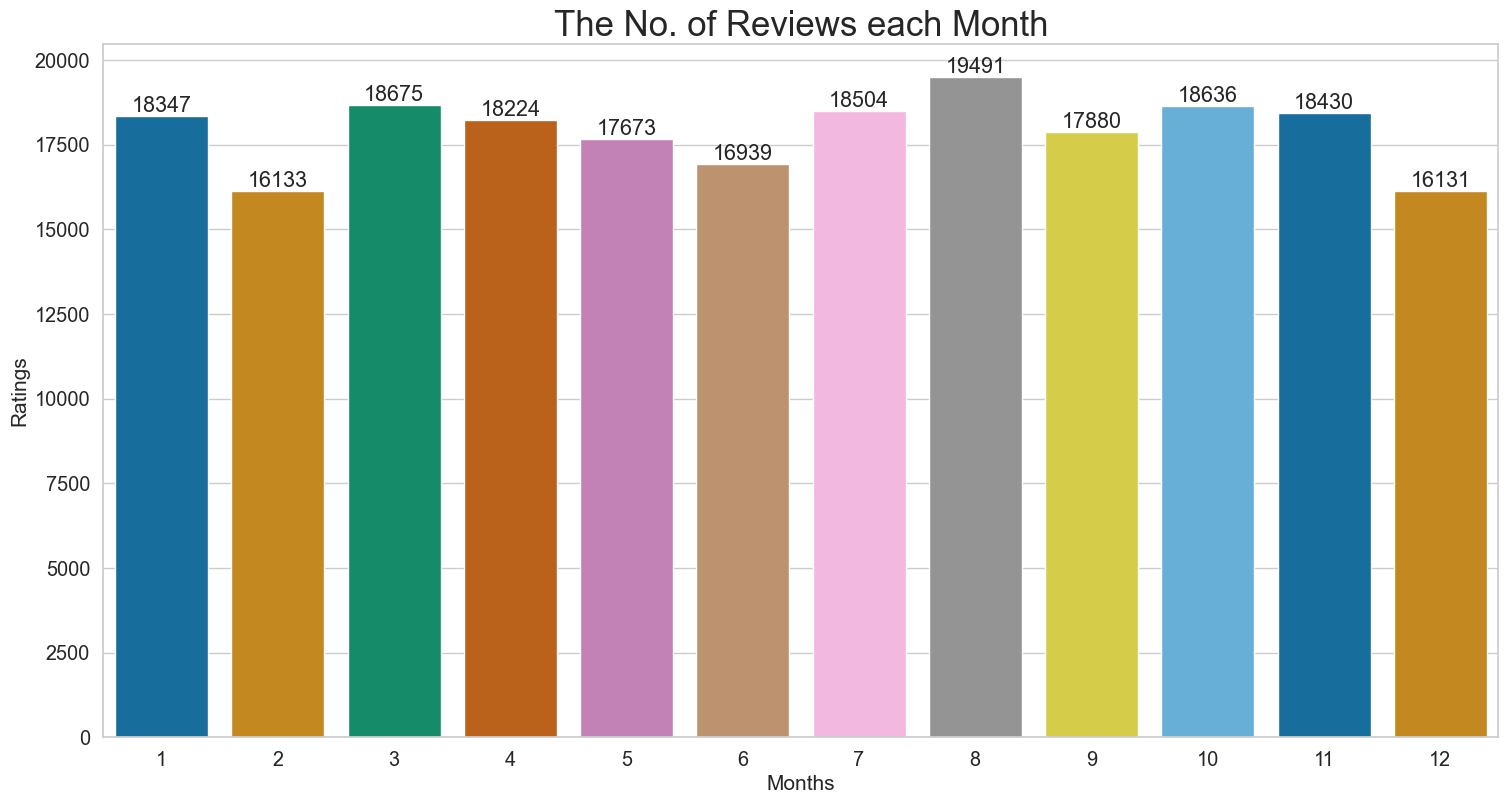

In [ ]:
plt.rcParams['figure.figsize'] = (18, 9)
sns_=sns.countplot(data['month'], palette ='colorblind')

for i in sns_.containers:
    sns_.bar_label(i,)

plt.title('The No. of Reviews each Month', fontsize = 25)
plt.xlabel('Months', fontsize = 15)
plt.ylabel('Ratings', fontsize = 15)
plt.show()

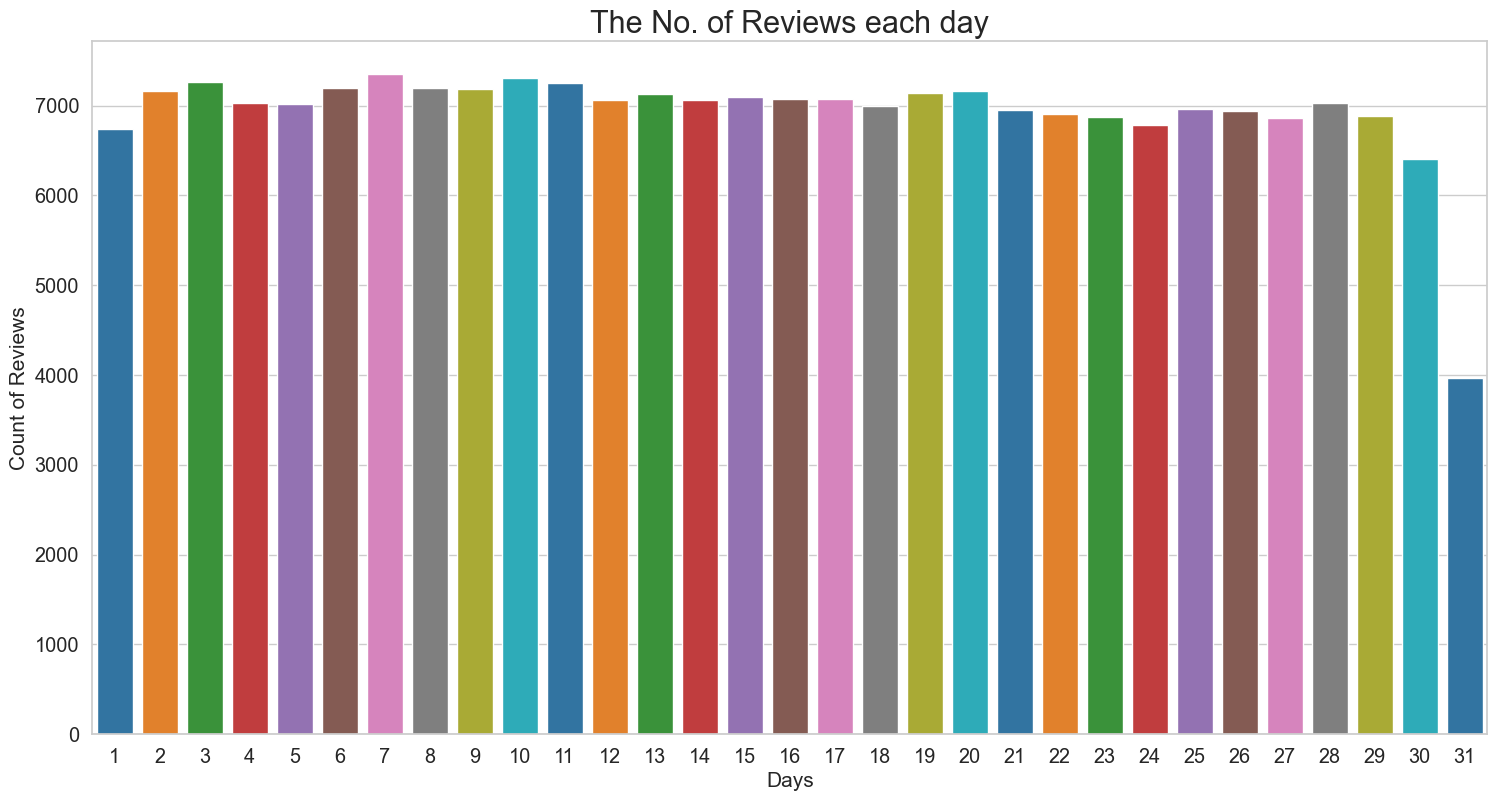

In [ ]:
plt.rcParams['figure.figsize'] = (18, 9)
sns_=sns.countplot(data['day'], palette ='tab10')

plt.title('The No. of Reviews each day', fontsize = 22)
plt.xlabel('Days', fontsize = 15)
plt.ylabel('Count of Reviews', fontsize = 15)
plt.show()

# Feature Engineering/ Data Preprocessing

In [ ]:
# changing to lower case
lower = data.review.str.lower()

# Replacing the repeating pattern of &#039;
pattern_remove = lower.str.replace("&#039;", "")

# Removing all the special Characters
special_remove = pattern_remove.str.replace(r'[^\w\d\s]',' ')

# Removing all the non ASCII characters
ascii_remove = special_remove.str.replace(r'[^\x00-\x7F]+',' ')

# Removing the leading and trailing Whitespaces
whitespace_remove = ascii_remove.str.replace(r'^\s+|\s+?$','')

# Replacing multiple Spaces with Single Space
multiw_remove = whitespace_remove.str.replace(r'\s+',' ')

# Replacing Two or more dots with one
data['review_clean'] = multiw_remove.str.replace(r'\.{2,}', ' ')

In [ ]:
# %pip install textblob

In [ ]:
from textblob import TextBlob
from nltk.corpus import stopwords
from collections import Counter
import warnings; warnings.simplefilter('ignore')
import nltk
import string
from nltk import ngrams
from nltk.tokenize import word_tokenize 
from nltk.stem import SnowballStemmer

# Removing the stopwords
stop_words = set(stopwords.words('english'))
data['review_clean'] = data['review_clean'].apply(lambda x: ' '.join(word for word in x.split() if word not in stop_words))

In [ ]:
# Removing the word stems using the Snowball Stemmer
Snow_ball = SnowballStemmer("english")
data['review_clean'] = data['review_clean'].apply(lambda x: " ".join(Snow_ball.stem(word) for word in x.split()))
# data.head(3)

In [ ]:
def sentiment(review):
    # Sentiment polarity of the reviews
    pol = []
    for i in review:
        analysis = TextBlob(i)
        pol.append(analysis.sentiment.polarity)
    return pol


data['sentiment'] = sentiment(data['review'])
data['sentiment_clean'] = sentiment(data['review_clean'])

In [134]:
from nltk.sentiment.vader import SentimentIntensityAnalyzer

In [135]:
sid = SentimentIntensityAnalyzer()

In [136]:
def sentiment_vader(review):
    return  sid.polarity_scores(review).get('compound')
    

In [63]:
# changing to lower case
lower = data.review.str.lower()

# Replacing the repeating pattern of &#039;
pattern_remove = lower.str.replace("&#039;", "")

# Removing all the special Characters
special_remove = pattern_remove.str.replace(r'[^\w\d\s]',' ')

# Removing all the non ASCII characters
ascii_remove = special_remove.str.replace(r'[^\x00-\x7F]+',' ')

# Removing the leading and trailing Whitespaces
whitespace_remove = ascii_remove.str.replace(r'^\s+|\s+?$','')

# Replacing multiple Spaces with Single Space
multiw_remove = whitespace_remove.str.replace(r'\s+',' ')

# Replacing Two or more dots with one
data['review_clean_ss'] = multiw_remove.str.replace(r'\.{2,}', ' ')

In [64]:
data['sentiment_clean_ss'] = sentiment(data['review_clean_ss'])

In [65]:
data = data.dropna(how="any", axis=0)

#Word count in each review
data['count_word']=data["review_clean_ss"].apply(lambda x: len(str(x).split()))

#Unique word count 
data['count_unique_word']=data["review_clean_ss"].apply(lambda x: len(set(str(x).split())))

#Letter count
data['count_letters']=data["review_clean_ss"].apply(lambda x: len(str(x)))

#punctuation count
data["count_punctuations"] = data["review"].apply(lambda x: len([c for c in str(x) if c in string.punctuation]))

#upper case words count
data["count_words_upper"] = data["review"].apply(lambda x: len([w for w in str(x).split() if w.isupper()]))

#title case words count
data["count_words_title"] = data["review"].apply(lambda x: len([w for w in str(x).split() if w.istitle()]))

#Number of stopwords
data["count_stopwords"] = data["review"].apply(lambda x: len([w for w in str(x).lower().split() if w in stop_words]))

#Average length of the words
data["mean_word_len"] = data["review_clean_ss"].apply(lambda x: np.mean([len(w) for w in str(x).split()]))

# Feature Selection

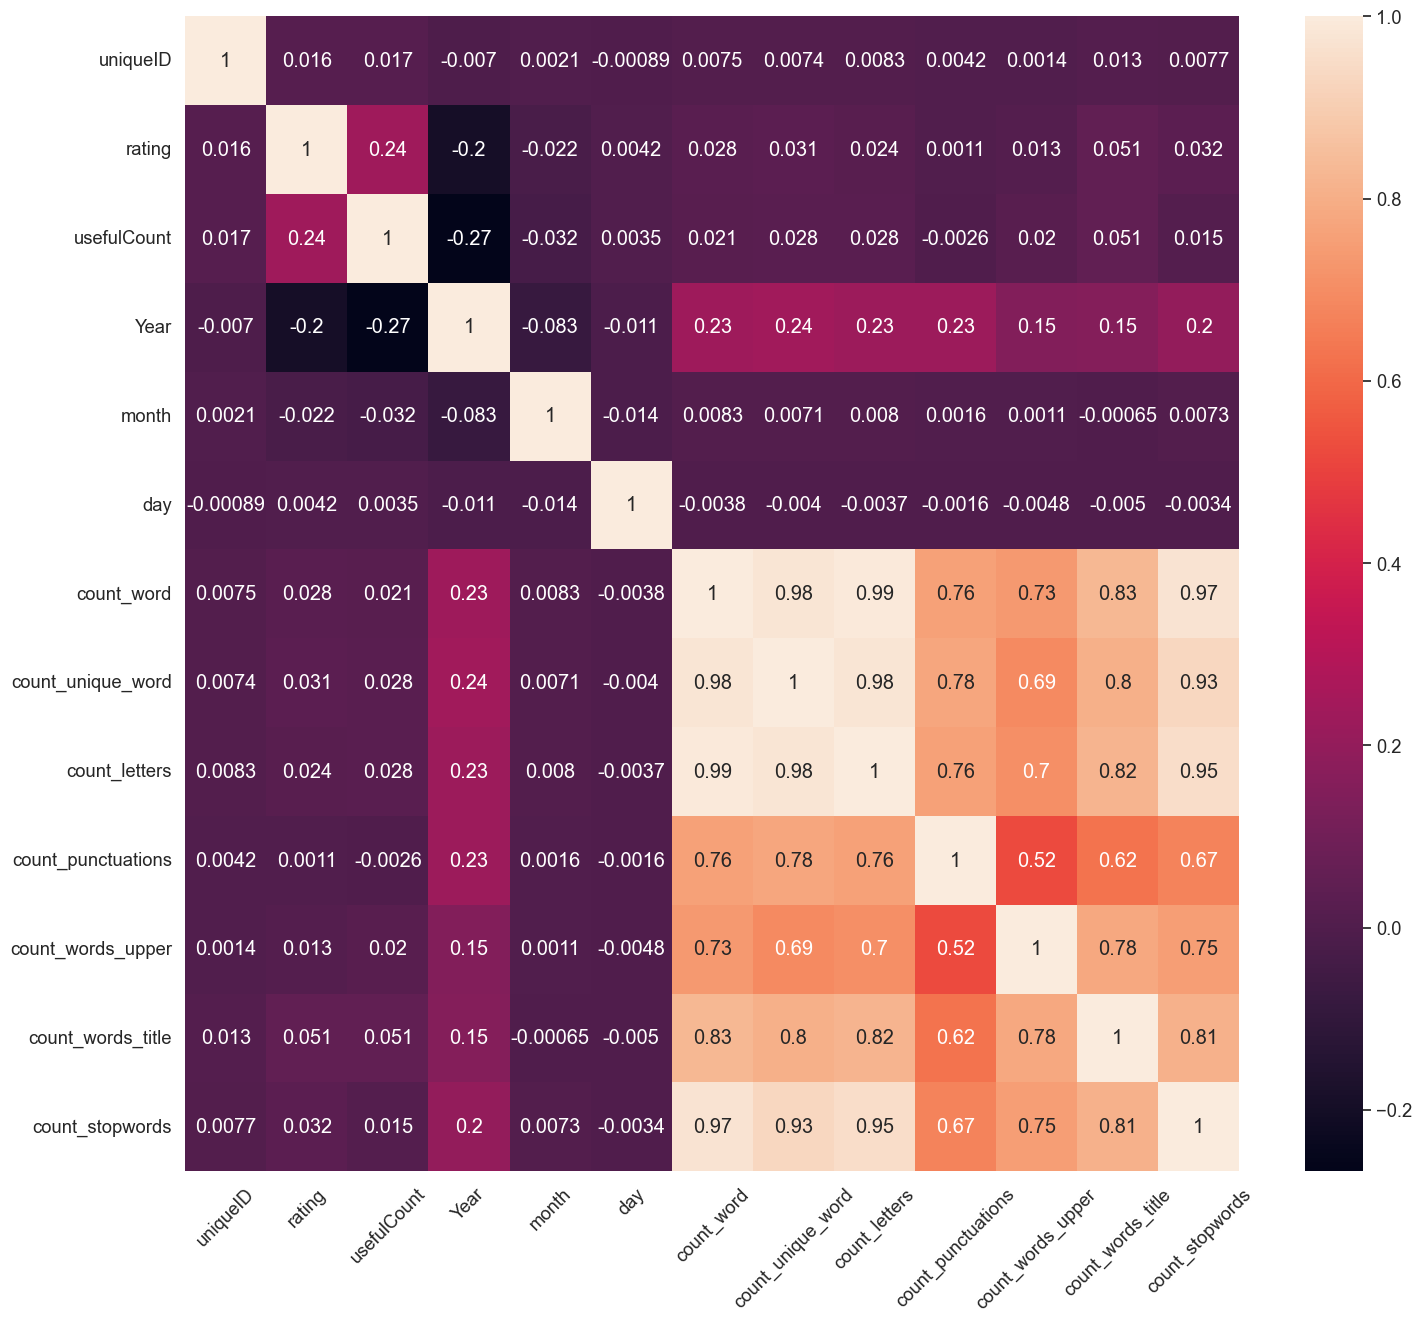

In [66]:
plt.rcParams['figure.figsize'] = [17,15]
sns.set(font_scale = 1.2)
corr = data.select_dtypes(include = 'int64').corr()
sns_ = sns.heatmap(corr, annot = True)
plt.setp(sns_.get_xticklabels(), rotation = 45)
plt.show()

#### Label Encoding

In [67]:
from sklearn.preprocessing import LabelEncoder
label_encoder_feat = {}
for feature in ['drugName', 'condition']:
    label_encoder_feat[feature] = LabelEncoder()
    data[feature] = label_encoder_feat[feature].fit_transform(data[feature])

#### After Label Encoding

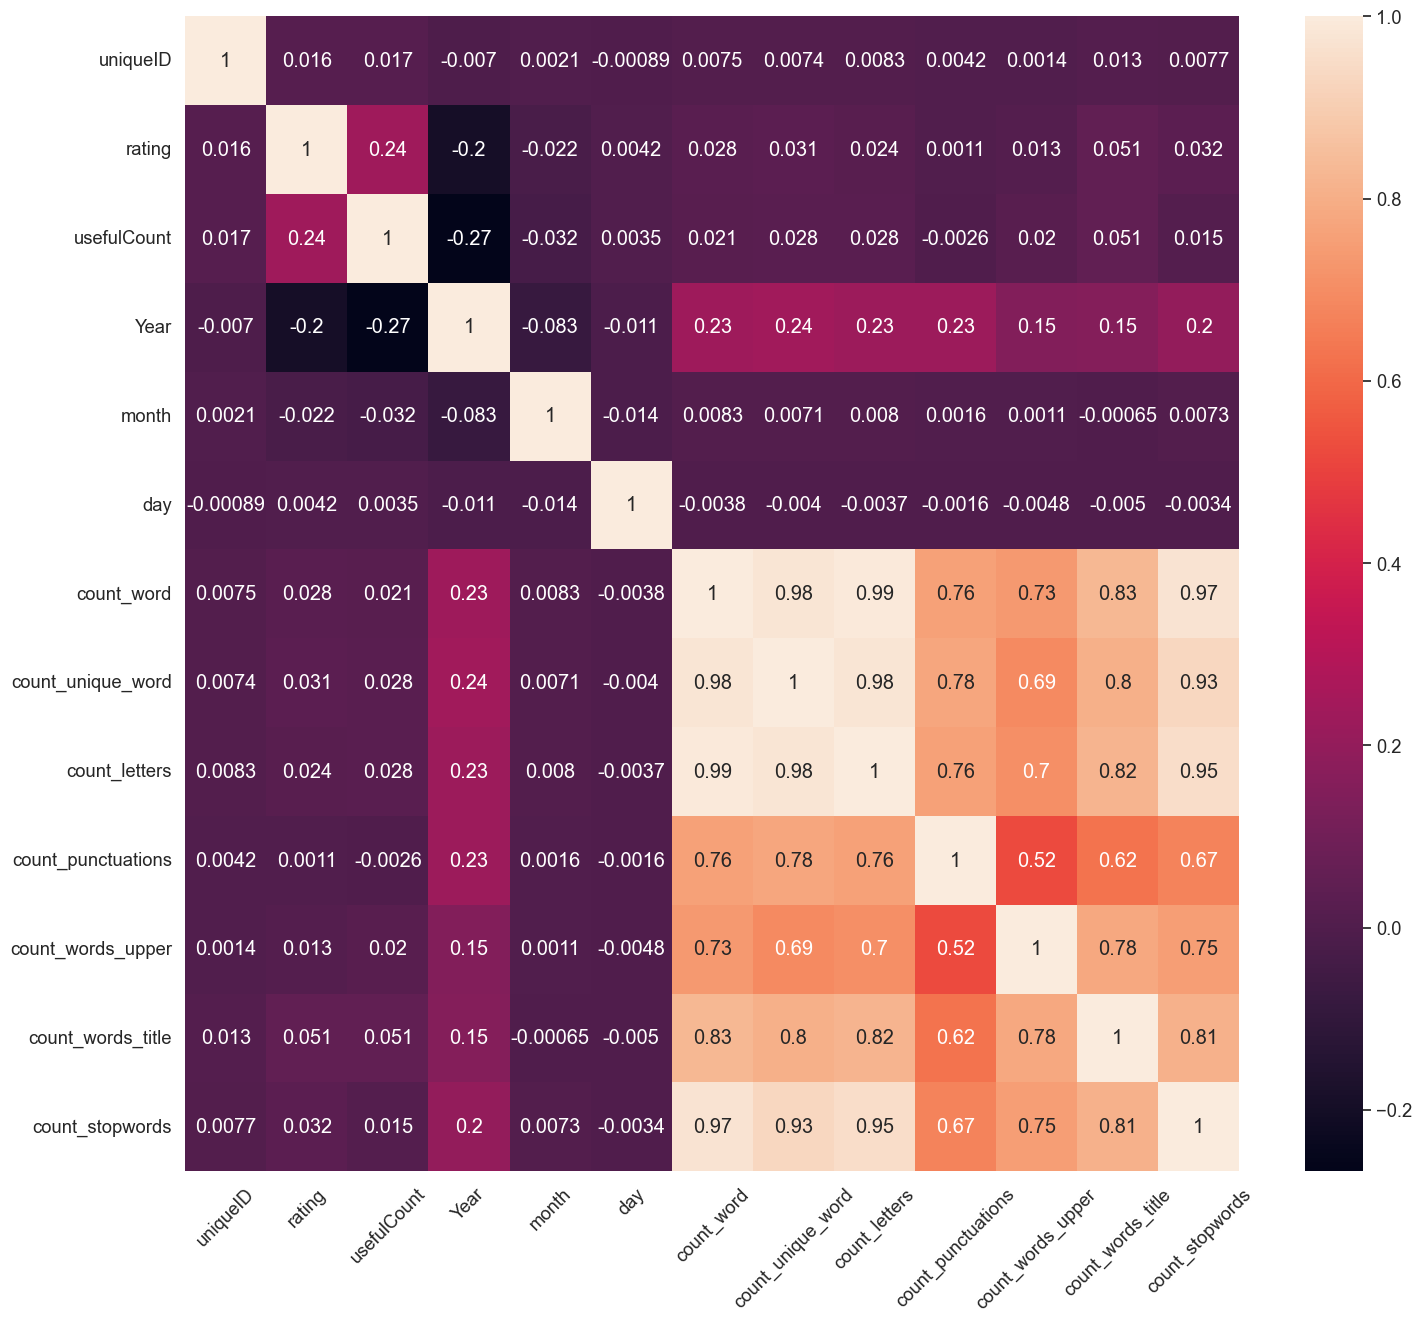

In [68]:
plt.rcParams['figure.figsize'] = [17,15]
sns.set(font_scale = 1.2)
corr = data.select_dtypes(include = 'int64').corr()
sns_ = sns.heatmap(corr, annot = True)
plt.setp(sns_.get_xticklabels(), rotation = 45)
plt.show()

# **TFIDF MODEL TRAINING**

In [69]:
data.loc[(data['sentiment_clean_ss'] > 0), 'SentimentLabel'] = 'Positive'
data.loc[(data['sentiment_clean_ss'] == 0), 'SentimentLabel'] = 'Neutral'
data.loc[(data['sentiment_clean_ss'] < 0), 'SentimentLabel'] = 'Negative'

In [ ]:
# data['sentiment_clean_ss_vader'].describe()

In [140]:
# data.loc[(data['sentiment_clean_ss_vader'] > 0.05), 'SentimentLabel_vader'] = 'Positive'
# data.loc[(data['sentiment_clean_ss_vader'] < 0.05 and data['sentiment_clean_ss_vader'] > -0.05), 'SentimentLabel_vader'] = 'Neutral'
# data.loc[(data['sentiment_clean_ss_vader'] < -0.05), 'SentimentLabel_vader'] = 'Negative'

In [70]:
data['SentimentLabel'].value_counts()

Positive    132670
Negative     72064
Neutral       9135
Name: SentimentLabel, dtype: int64

In [71]:
# data.head()

In [72]:
# csv_file_path = 'model_ready_data.csv'
# data.to_csv(csv_file_path, index=False)  # Set index=False to exclude row numbers in the CSV


In [62]:
data = pd.read_csv('model_ready_data.csv')
data_for_train = data.drop(['SentimentLabel'], axis=1)

,uniqueID,drugName,condition,review,rating,date,usefulCount,review_clean,sentiment,sentiment_clean,review_clean_ss,sentiment_clean_ss,count_word,count_unique_word,count_letters,count_punctuations,count_words_upper,count_words_title,count_stopwords,mean_word_len
0,206461,3421,480,"""It has no side effect, I take it in combinati...",9,20-May-12,27,side effect take combination bystolic 5 mg fis...,0.000000,0.000000,it has no side effect i take it in combination...,0.000000,17,16,76,3,1,6,7,3.529412
1,95260,1536,80,"""My son is halfway through his fourth week of ...",8,27-Apr-10,192,son halfway fourth week intuniv became concern...,0.168333,0.148611,my son is halfway through his fourth week of i...,0.168333,141,97,716,23,2,13,69,4.085106
2,92703,1983,175,"""I used to take another oral contraceptive, wh...",5,14-Dec-09,17,used take another oral contraceptive 21 pill c...,0.067210,0.119805,i used to take another oral contraceptive whic...,0.067210,134,89,714,34,6,15,59,4.335821
3,138000,2446,175,"""This is my first time using any form of birth...",8,3-Nov-15,10,first time using form birth control im glad we...,0.179545,0.262500,this is my first time using any form of birth ...,0.179545,91,58,432,15,4,9,45,3.758242
4,35696,553,593,"""Suboxone has completely turned my life around...",9,27-Nov-16,37,suboxone completely turned life around feel he...,0.194444,0.194444,suboxone has completely turned my life around ...,0.194444,125,85,670,28,7,15,60,4.368000


In [73]:
from sklearn.model_selection import train_test_split
X_train,X_test,Y_train, Y_test = train_test_split(data_for_train, data['SentimentLabel'], test_size=0.25, random_state=30)
print('Train: ',X_train.shape,Y_train.shape,'Test: ',(X_test.shape,Y_test.shape))

Train:  (160401, 20) (160401,) Test:  ((53468, 20), (53468,))


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
vectorizer = TfidfVectorizer(max_features=5000)
tf_x_train = vectorizer.fit_transform(X_train)
tf_x_test = vectorizer.transform(X_test)

In [ ]:
from sklearn.svm import LinearSVC
clf = LinearSVC(random_state=0)

In [ ]:
clf.fit(tf_x_train,Y_train)

ValueError: Found input variables with inconsistent numbers of samples: [20, 160401]

In [52]:
y_test_pred_linear=clf.predict(tf_x_test)


In [53]:
from sklearn.metrics import classification_report
report=classification_report(Y_test, y_test_pred_linear,output_dict=True)

In [32]:
report

{'Negative': {'precision': 0.9070044878713855,
  'recall': 0.8802028777771652,
  'f1-score': 0.893402719489676,
  'support': 18139},
 'Neutral': {'precision': 0.9454545454545454,
  'recall': 0.8632590650939275,
  'f1-score': 0.9024891527746061,
  'support': 2289},
 'Positive': {'precision': 0.9319615099925981,
  'recall': 0.9526937046004843,
  'f1-score': 0.9422135747960787,
  'support': 33040},
 'accuracy': 0.9242724620333658,
 'macro avg': {'precision': 0.9281401811061764,
  'recall': 0.8987185491571923,
  'f1-score': 0.9127018156867869,
  'support': 53468},
 'weighted avg': {'precision': 0.9240724947669626,
  'recall': 0.9242724620333658,
  'f1-score': 0.9239538810276566,
  'support': 53468}}

In [54]:
from sklearn.linear_model import LogisticRegression
clf = LogisticRegression(max_iter=1000,solver='saga')

In [55]:
clf.fit(tf_x_train,Y_train)


LogisticRegression(max_iter=1000, solver='saga')

In [56]:
y_test_pred_log=clf.predict(tf_x_test)


In [57]:
from sklearn.metrics import classification_report
report=classification_report(Y_test, y_test_pred_log,output_dict=True)

In [58]:
report

{'Negative': {'precision': 0.9085903083700441,
  'recall': 0.8641600970285022,
  'f1-score': 0.8858184284140036,
  'support': 18139},
 'Neutral': {'precision': 0.9276923076923077,
  'recall': 0.7903014416775884,
  'f1-score': 0.8535031847133757,
  'support': 2289},
 'Positive': {'precision': 0.9211171423568552,
  'recall': 0.9552966101694915,
  'f1-score': 0.9378955813746174,
  'support': 33040},
 'accuracy': 0.9173150295503852,
 'macro avg': {'precision': 0.9191332528064023,
  'recall': 0.8699193829585274,
  'f1-score': 0.8924057315006656,
  'support': 53468},
 'weighted avg': {'precision': 0.9171489055005314,
  'recall': 0.9173150295503852,
  'f1-score': 0.9166155321206682,
  'support': 53468}}

In [41]:
from sklearn.ensemble import VotingClassifier


In [37]:
lr = LogisticRegression(max_iter=1000,solver='saga')
svc = LinearSVC(random_state=0)

In [38]:
Text_blob_model_svc=svc.fit(tf_x_train,Y_train)
Text_blob_model_lr=lr.fit(tf_x_train,Y_train)

y1_pred_svc= Text_blob_model_svc.predict(tf_x_test)
y1_pred_lr = Text_blob_model_lr.predict(tf_x_test)

In [42]:
voting_classifier = VotingClassifier(estimators=[('logistic_regression', lr),('svm', svc)], voting='hard')  


In [43]:
voting_classifier.fit(tf_x_train, Y_train)


VotingClassifier(estimators=[('logistic_regression',
                              LogisticRegression(max_iter=1000, solver='saga')),
                             ('svm', LinearSVC(random_state=0))])

In [44]:
ensemble_pred_textblob = voting_classifier.predict(tf_x_test)


In [45]:
from sklearn.metrics import confusion_matrix, classification_report
from sklearn import metrics



In [46]:
conf_textblob= confusion_matrix(Y_test, ensemble_pred_textblob)
cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix = conf_textblob, display_labels = [False, True])

In [47]:
accuracy_textblob =  metrics.accuracy_score(Y_test,ensemble_pred_textblob)
print(accuracy_textblob)

0.9224769955861449


In [48]:
print(classification_report(Y_test,ensemble_pred_textblob))


              precision    recall  f1-score   support

    Negative       0.89      0.89      0.89     18139
     Neutral       0.94      0.84      0.89      2289
    Positive       0.94      0.95      0.94     33040

    accuracy                           0.92     53468
   macro avg       0.92      0.89      0.91     53468
weighted avg       0.92      0.92      0.92     53468



In [49]:
labels = ['positive','negative','neutral']


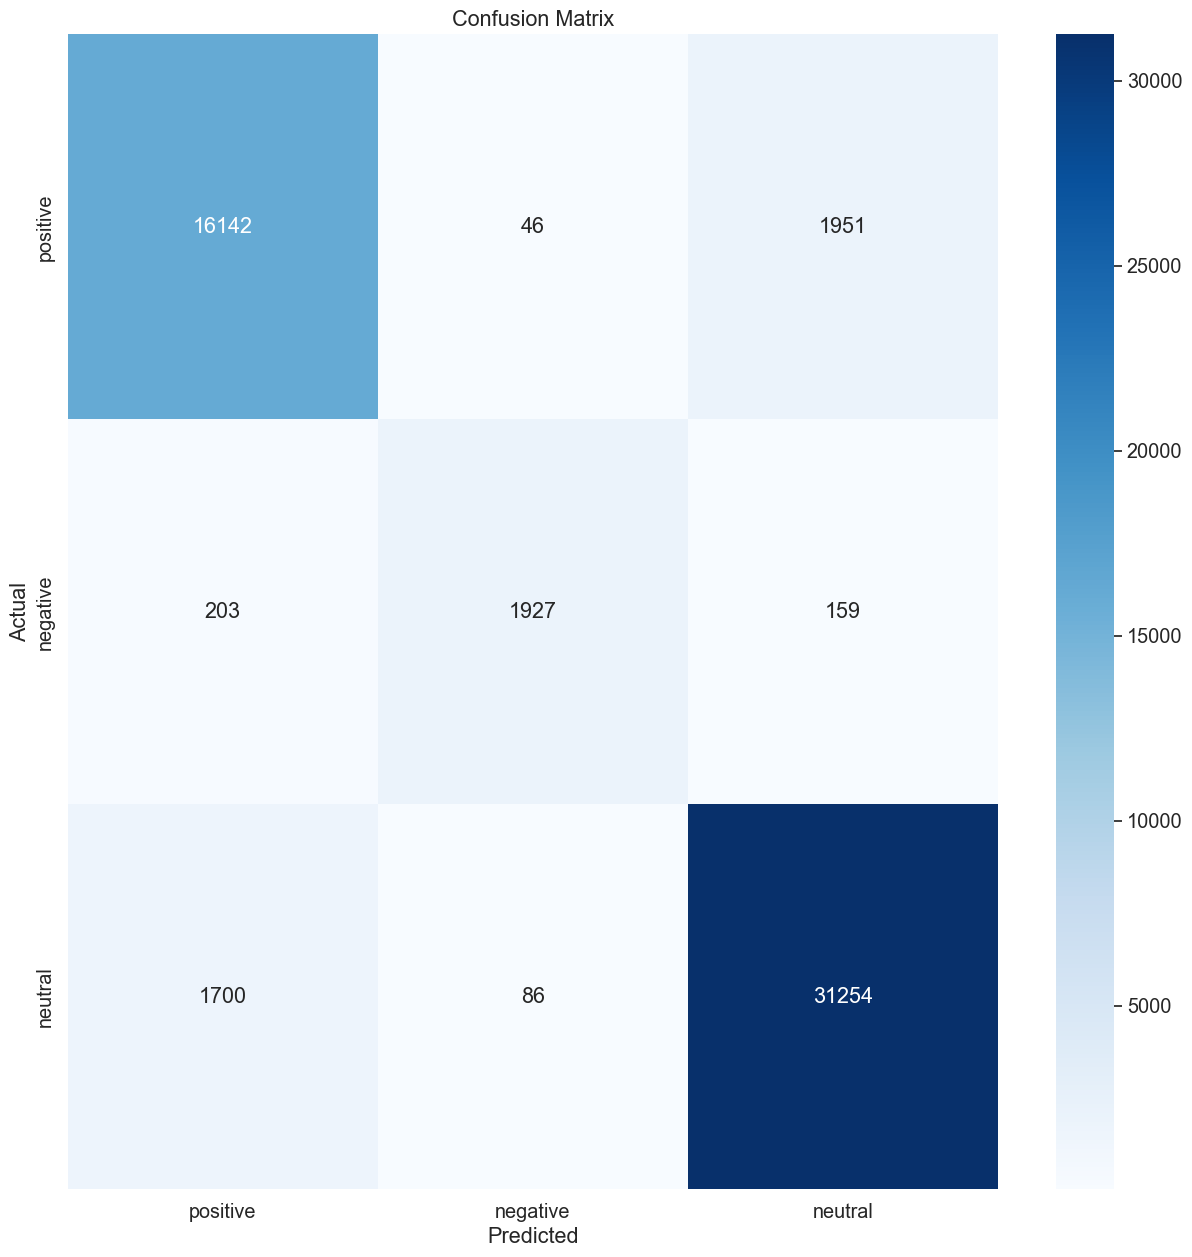

In [50]:
sns.heatmap(conf_textblob, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [51]:
def userful_count(data,feature):
    '''this function takes dataframe and feature as input and normalize the given feature'''
    
    max_value = data[feature].max()
    min_value = data[feature].min()
    data[feature] = (data[feature] - min_value) / (max_value - min_value)
    return data 

In [85]:
X_test['sentiment_clean_ss'] = y_test_pred_log
X_test['LinearSVC'] = y_test_pred_linear 
X_test['Ensemble'] = ensemble_pred_textblob

In [77]:

X_test =  userful_count(X_test,'usefulCount') 
#X_test['usefulCount'] = X_test['usefulCount']/X_test['user_size']

# X_test['rec_score'] = (X_test['LogisticRegression']+X_test['LinearSVC']+X_test['Ensemble'])*X_test['usefulCount']

# X_test.head()

In [79]:
X_test['usefulCount'] = pd.to_numeric(X_test['usefulCount'], errors='coerce')
X_test['LogisticRegression'] = pd.to_numeric(X_test['LogisticRegression'], errors='coerce')
X_test['LinearSVC'] = pd.to_numeric(X_test['LinearSVC'], errors='coerce')
X_test['Ensemble'] = pd.to_numeric(X_test['Ensemble'], errors='coerce')


In [88]:
# Perform the calculation
X_test['rec_score'] = (X_test['sentiment']) * X_test['usefulCount']


In [89]:
X_test.head()


,uniqueID,drugName,condition,review,rating,date,usefulCount,review_clean,sentiment,sentiment_clean,...,count_letters,count_punctuations,count_words_upper,count_words_title,count_stopwords,mean_word_len,LogisticRegression,LinearSVC,Ensemble,rec_score
125759,125710,1366,298,"""Flagyl took away all of my energy for 23 hour...",5,20-Jul-12,0.045701,flagyl took away energy 23 hours day first day...,0.016667,0.125000,...,312,9,7,9,30,3.890625,NaN,Positive,Positive,0.000762
94872,194831,1864,750,"""I love this stuff, once we got the seizures u...",10,12-Apr-16,0.032533,love stuff got seizures control correct dose s...,0.225000,0.225000,...,133,5,3,2,13,4.153846,NaN,Positive,Positive,0.007320
163956,57740,48,159,"""Severe neck and back pain.""",9,21-May-13,0.017041,severe neck back pain,0.000000,0.000000,...,25,3,0,1,1,4.200000,NaN,Neutral,Neutral,0.000000
86007,125533,1104,241,"""I suffer from Irritable Bowel Syndrome-Consti...",5,18-May-14,0.024012,suffer irritable bowel syndrome constipation s...,0.145833,0.119792,...,592,22,8,14,56,4.156522,NaN,Positive,Positive,0.003502
109199,163938,1566,87,"""I had terrible acne at 13. PhisoHex was an o...",10,13-Feb-14,0.000775,terrible acne 13 phisohex counter cleanser ins...,-0.012500,-0.012500,...,335,8,4,5,35,3.869565,NaN,Negative,Negative,-0.000010


In [90]:
df = X_test.groupby(['condition','drugName']).agg({'rec_score':['sum']})

In [91]:
df.tail()

rec_score
                         sum
condition drugName          
914       1579      0.000000
915       146       0.001214
          1007      0.000904
          2234      0.001872
          2253     -0.004725

In [94]:
X_test[X_test['condition']==914].sort_values(by=['rec_score'],ascending=False)

,uniqueID,drugName,condition,review,rating,date,usefulCount,review_clean,sentiment,sentiment_clean,...,count_letters,count_punctuations,count_words_upper,count_words_title,count_stopwords,mean_word_len,LogisticRegression,LinearSVC,Ensemble,rec_score
57327,176070,1579,914,"""worked perfect for 20 years""",10,6-Dec-17,0.0,worked perfect 20 years,1.0,1.0,...,27,2,0,0,1,4.6,NaN,Positive,Positive,0.0


LSTM MODELLING

In [98]:
# The maximum number of words to be used. (most frequent)
MAX_NB_WORDS = 50000
# Max number of words in each complaint.
MAX_SEQUENCE_LENGTH = 250
# This is fixed.
EMBEDDING_DIM = 100
tokenizer = Tokenizer(num_words=MAX_NB_WORDS, filters='!"#$%&()*+,-./:;<=>?@[\]^_`{|}~', lower=True)
tokenizer.fit_on_texts(data['review'].values)
word_index = tokenizer.word_index
print('Found %s unique tokens.' % len(word_index))

Found 59943 unique tokens.


In [100]:
X = tokenizer.texts_to_sequences(data['review'].values)
X = pad_sequences(X, maxlen=MAX_SEQUENCE_LENGTH)
print('Shape of data tensor:', X.shape)

Shape of data tensor: (213869, 250)


In [101]:
Y = pd.get_dummies(data['SentimentLabel']).values
print('Shape of label tensor:', Y.shape)

Shape of label tensor: (213869, 3)


In [107]:
X_train, X_test, Y_train, Y_test = train_test_split(X,Y, test_size = 0.10, random_state = 42)
print(X_train.shape,Y_train.shape)
print(X_test.shape,Y_test.shape)

(192482, 250) (192482, 3)
(21387, 250) (21387, 3)


In [110]:
from keras.layers import SpatialDropout1D, Embedding, LSTM, Dense
from keras.models import Sequential
from keras.callbacks import EarlyStopping

# Assuming you have 3 classes for classification
num_classes = 3

model = Sequential()
model.add(Embedding(MAX_NB_WORDS, EMBEDDING_DIM, input_length=X.shape[1]))
model.add(SpatialDropout1D(0.2))
model.add(LSTM(100, dropout=0.2, recurrent_dropout=0.2))
model.add(Dense(num_classes, activation='softmax'))  # Output layer with softmax activation

model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

epochs = 5
batch_size = 64

history = model.fit(X_train, Y_train, epochs=epochs, batch_size=batch_size, validation_split=0.1, callbacks=[EarlyStopping(monitor='val_loss', patience=3, min_delta=0.0001)])


Epoch 1/5
2707/2707 [==============================] - 4318s 2s/step - loss: 0.3380 - accuracy: 0.8598 - val_loss: 0.1797 - val_accuracy: 0.9350
Epoch 2/5
2707/2707 [==============================] - 3446s 1s/step - loss: 0.1430 - accuracy: 0.9496 - val_loss: 0.1318 - val_accuracy: 0.9554
Epoch 3/5
2707/2707 [==============================] - 3545s 1s/step - loss: 0.0979 - accuracy: 0.9661 - val_loss: 0.1021 - val_accuracy: 0.9651
Epoch 4/5
2707/2707 [==============================] - 4353s 2s/step - loss: 0.0693 - accuracy: 0.9764 - val_loss: 0.0989 - val_accuracy: 0.9688
Epoch 5/5
2707/2707 [==============================] - 4177s 2s/step - loss: 0.0517 - accuracy: 0.9824 - val_loss: 0.1116 - val_accuracy: 0.9654


In [111]:
accr = model.evaluate(X_test,Y_test)
print('Test set\n  Loss: {:0.3f}\n  Accuracy: {:0.3f}'.format(accr[0],accr[1]))

669/669 [==============================] - 40s 60ms/step - loss: 0.1114 - accuracy: 0.9642
Test set
  Loss: 0.111
  Accuracy: 0.964


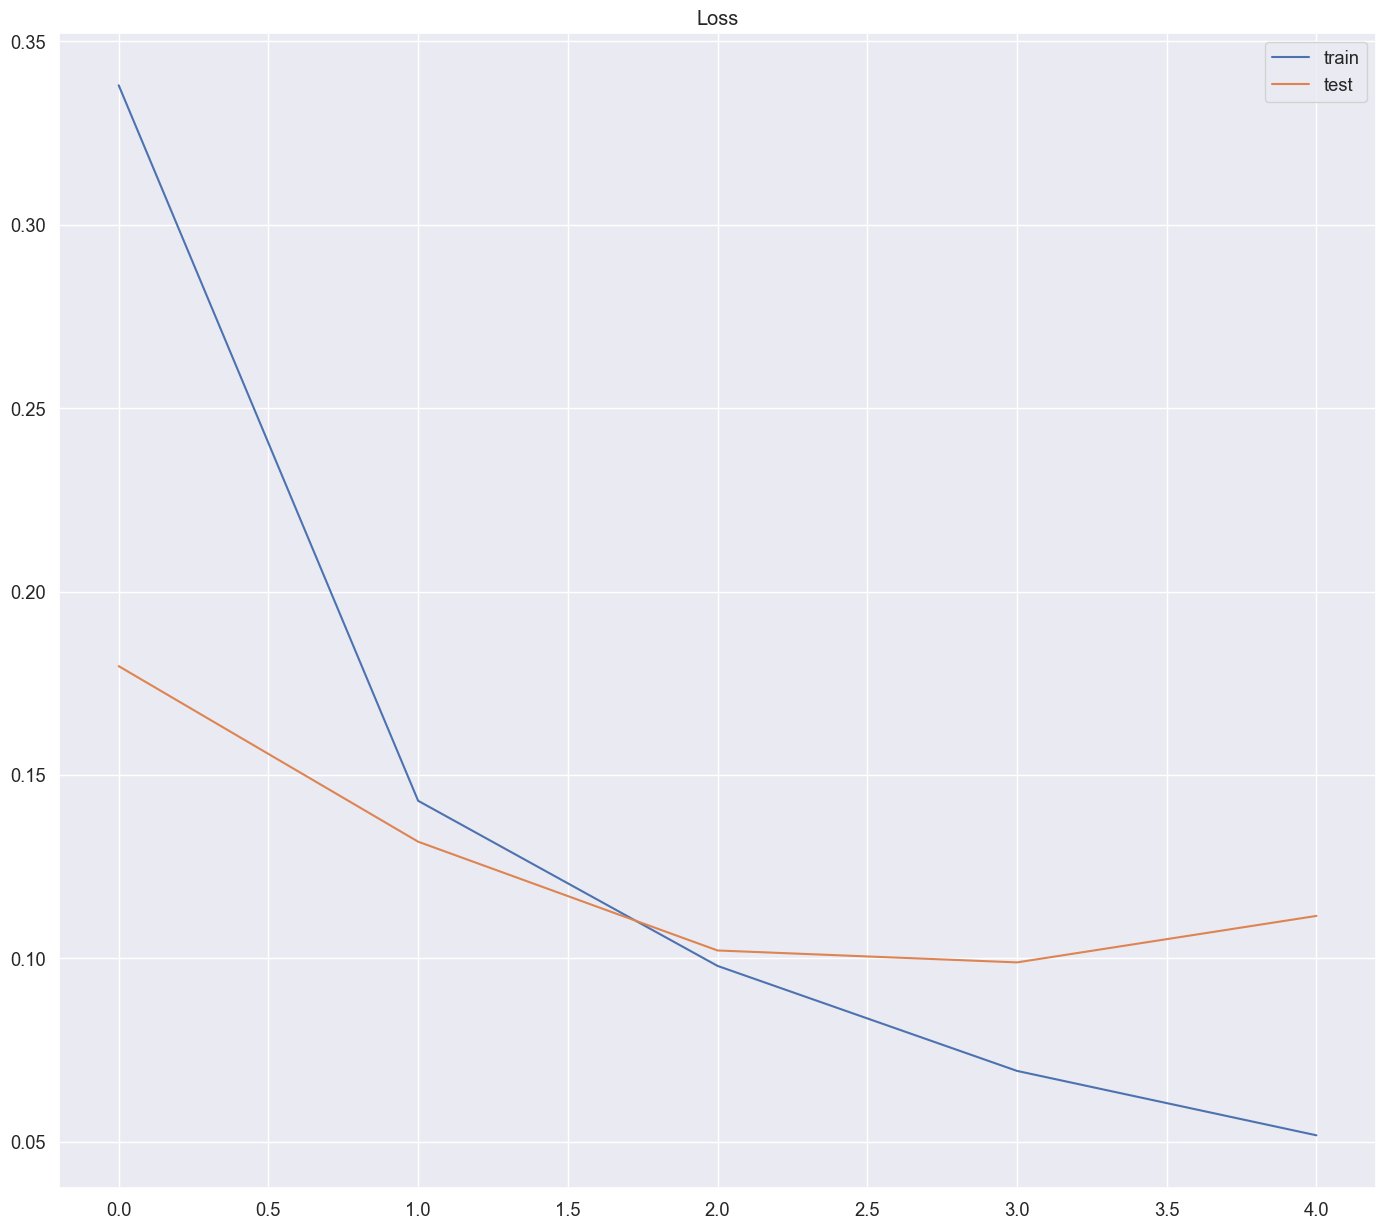

In [112]:
plt.title('Loss')
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='test')
plt.legend()
plt.show()

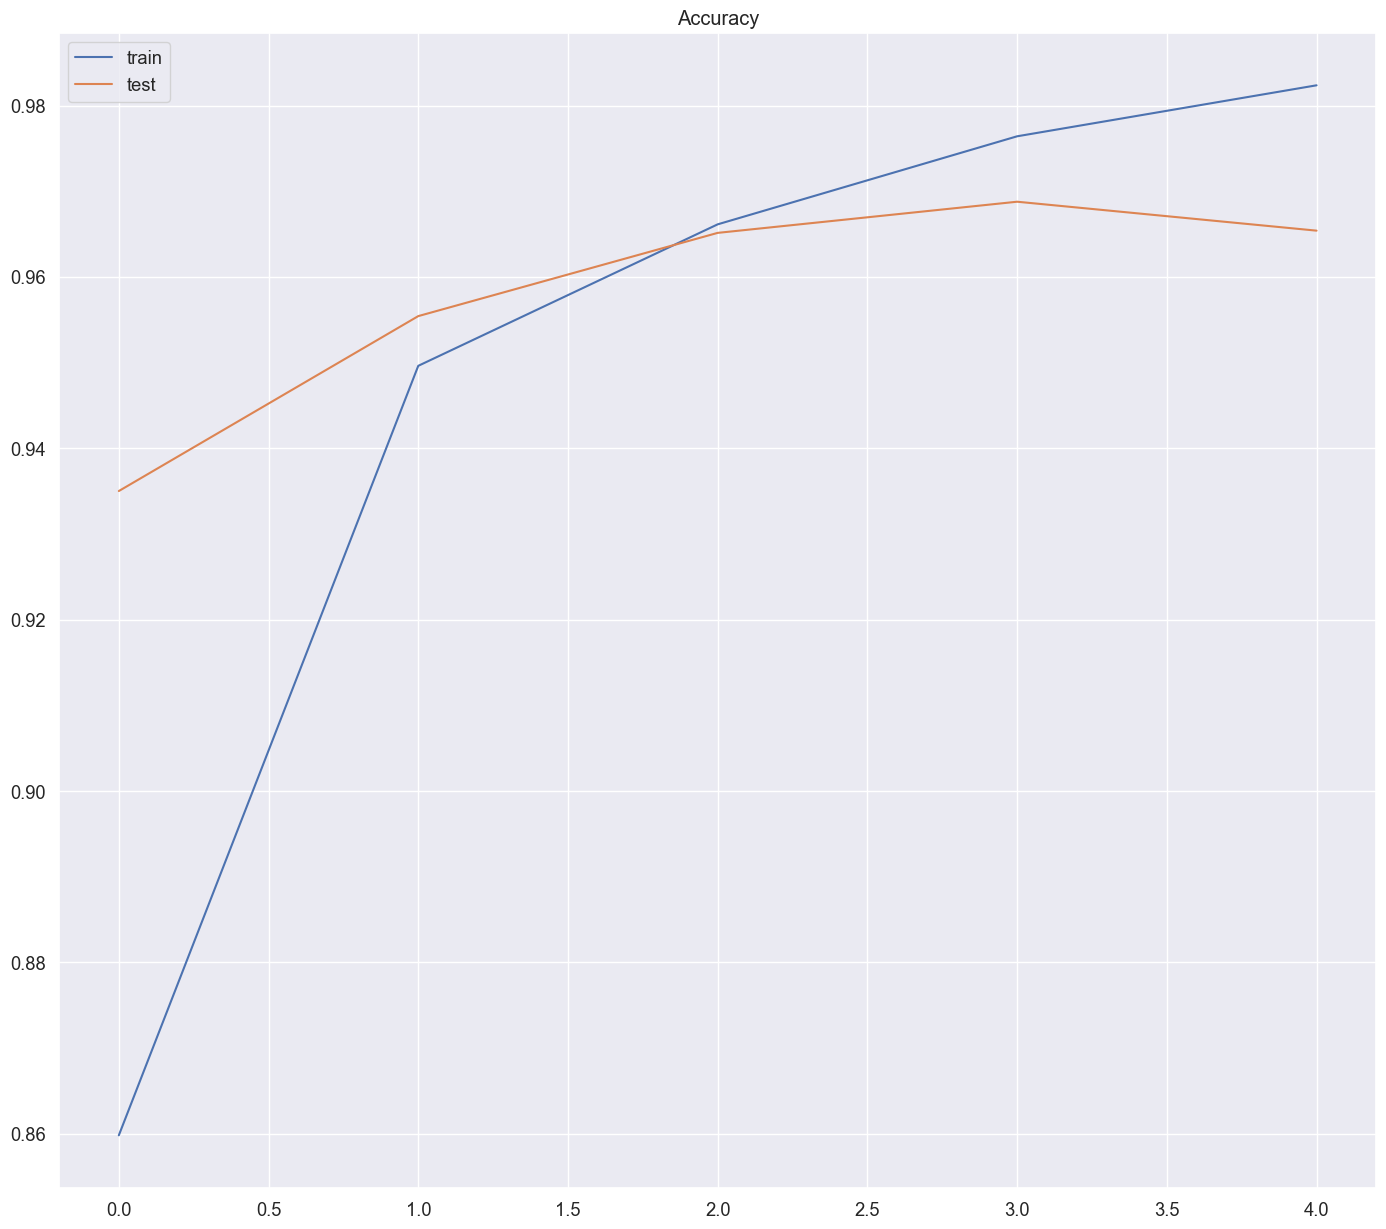

In [115]:
plt.title('Accuracy')
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='test')
plt.legend()
plt.show()

In [131]:
new_complaint = ['The drug is really helpful and it has not side effects']
seq = tokenizer.texts_to_sequences(new_complaint)
padded = pad_sequences(seq, maxlen=MAX_SEQUENCE_LENGTH)
pred = model.predict(padded)
print(pred)
#labels[np.argmax(pred)]

[[0.00257483 0.00245323 0.9949719 ]]


BERT